In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session.

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aayushaswal27/aisleguard-bev/bev_dataset.npz


In [2]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/aayushaswal27/aisleguard-bev/bev_dataset.npz


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(ch)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)


class BRIN(nn.Module):
    """
    BEV Risk Interaction Network.
    Input:  (B, 6, 64, 64) bird's-eye tensors
    Output: (B, 3) logits for SAFE / CAUTION / IMMINENT
    """
    def __init__(self, in_channels=6, num_classes=3):
        super().__init__()
        # stem: 6 channels -> 32
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU())

        self.res1  = ResidualBlock(32)                    # 64x64
        self.down1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU())                # 32x32
        self.res2  = ResidualBlock(64)

        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU())               # 16x16
        # dilated block: wide receptive field so distant agents interact
        self.res3  = ResidualBlock(128)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.down1(x); x = self.res2(x)
        x = self.down2(x); x = self.res3(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# your real Kaggle path
data = np.load("/kaggle/input/datasets/aayushaswal27/aisleguard-bev/bev_dataset.npz")
X_np = data["X"]          # keep as numpy, no full torch copy
y_np = data["y"]
print("Loaded:", X_np.shape, f"{X_np.nbytes/1e9:.2f} GB")

# lazy dataset — converts one sample at a time (memory-safe)
class BEVDataset(Dataset):
    def __init__(self, X, y):
        self.X = X; self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), int(self.y[i])

ds = BEVDataset(X_np, y_np)

counts = np.bincount(y_np)
weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print("Class counts:", counts.tolist())

n_val = int(0.15 * len(ds))
train_ds, val_ds = random_split(ds, [len(ds)-n_val, n_val],
                                generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)

model = BRIN().to(device)   # BRIN class from cell 1
print(sum(p.numel() for p in model.parameters()), "parameters")

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)          # lowered from 1e-3
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

def evaluate(loader):
    model.eval()
    correct = total = 0
    pc_correct = torch.zeros(3); pc_total = torch.zeros(3)
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item(); total += yb.size(0)
            for c in range(3):
                m = yb == c
                pc_total[c] += m.sum().item()
                pc_correct[c] += (preds[m] == c).sum().item()
    recall = (pc_correct / pc_total.clamp(min=1)).tolist()
    return correct/total, recall

EPOCHS = 20
best_imminent = 0.0
for epoch in range(EPOCHS):
    model.train(); running = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        running += loss.item()
    scheduler.step()                       # shrink LR once per epoch
    acc, recall = evaluate(val_loader)
    msg = (f"Epoch {epoch+1:2d}  loss={running/len(train_loader):.3f}  "
           f"val_acc={acc:.3f}  recall[S/C/I]="
           f"[{recall[0]:.2f}/{recall[1]:.2f}/{recall[2]:.2f}]")

    # save best model: strong IMMINENT recall AND not ignoring SAFE
    if recall[2] > best_imminent and recall[0] > 0.7:
        best_imminent = recall[2]
        torch.save(model.state_dict(), "/kaggle/working/brin_best.pt")
        msg += f"   <- saved (IMMINENT {recall[2]:.2f})"
    print(msg)

print(f"\nBest IMMINENT recall saved: {best_imminent:.2f}")

Device: cuda
Loaded: (160000, 6, 64, 64) 15.73 GB
Class counts: [101624, 16666, 41710]
491427 parameters
Epoch  1  loss=0.649  val_acc=0.680  recall[S/C/I]=[0.57/0.95/0.83]
Epoch  2  loss=0.432  val_acc=0.719  recall[S/C/I]=[0.64/0.54/0.96]
Epoch  3  loss=0.379  val_acc=0.848  recall[S/C/I]=[0.98/0.59/0.64]   <- saved (IMMINENT 0.64)
Epoch  4  loss=0.342  val_acc=0.771  recall[S/C/I]=[0.75/0.98/0.74]   <- saved (IMMINENT 0.74)
Epoch  5  loss=0.317  val_acc=0.266  recall[S/C/I]=[0.00/0.00/1.00]
Epoch  6  loss=0.299  val_acc=0.767  recall[S/C/I]=[0.76/0.99/0.69]
Epoch  7  loss=0.278  val_acc=0.825  recall[S/C/I]=[0.79/0.61/0.98]   <- saved (IMMINENT 0.98)
Epoch  8  loss=0.265  val_acc=0.874  recall[S/C/I]=[0.86/0.91/0.90]
Epoch  9  loss=0.250  val_acc=0.287  recall[S/C/I]=[0.00/0.21/1.00]
Epoch 10  loss=0.238  val_acc=0.387  recall[S/C/I]=[0.19/0.03/1.00]
Epoch 11  loss=0.226  val_acc=0.273  recall[S/C/I]=[0.00/0.08/1.00]
Epoch 12  loss=0.213  val_acc=0.916  recall[S/C/I]=[0.97/0.75/0.84

In [5]:
torch.save(model.state_dict(), "/kaggle/working/brin_final.pt")
print("saved final")

saved final


In [6]:
import shutil
shutil.make_archive("/kaggle/working/brin_models", "zip", "/kaggle/working")
print("zipped")

zipped


In [7]:
import numpy as np

model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        p = model(xb).argmax(1).cpu().numpy()
        all_pred.extend(p); all_true.extend(yb.numpy())
all_true = np.array(all_true); all_pred = np.array(all_pred)

def rec(t, p):
    return [ (p[t==c]==c).mean() if (t==c).sum() else 0 for c in range(3) ]

br = rec(all_true, all_pred)
print("=== BRIN (learned CNN) ===")
print(f"accuracy: {(all_pred==all_true).mean():.3f}")
print(f"recall [S/C/I]: [{br[0]:.2f}/{br[1]:.2f}/{br[2]:.2f}]")

maj = np.zeros_like(all_true)   # always predict SAFE
mr = rec(all_true, maj)
print("\n=== Naive baseline (always SAFE) ===")
print(f"accuracy: {(maj==all_true).mean():.3f}")
print(f"recall [S/C/I]: [{mr[0]:.2f}/{mr[1]:.2f}/{mr[2]:.2f}]")

print(f"\nBRIN catches {br[2]*100:.0f}% of collisions; naive baseline catches {mr[2]*100:.0f}%.")

=== BRIN (learned CNN) ===
accuracy: 0.924
recall [S/C/I]: [0.92/0.92/0.94]

=== Naive baseline (always SAFE) ===
accuracy: 0.631
recall [S/C/I]: [1.00/0.00/0.00]

BRIN catches 94% of collisions; naive baseline catches 0%.


In [8]:
import torch
torch.save(model.state_dict(), "/kaggle/working/brin_final.pt")
print("saved brin_final.pt — now download it directly from the Output panel")

saved brin_final.pt — now download it directly from the Output panel


In [9]:
# Grad-CAM setup — loads saved model, no retrain
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np

# BRIN class (paste if not already defined this session)
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1); self.bn1 = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1); self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        idn = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + idn)

class BRIN(nn.Module):
    def __init__(self, in_channels=6, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_channels,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.res1 = ResidualBlock(32)
        self.down1 = nn.Sequential(nn.Conv2d(32,64,3,stride=2,padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.res2 = ResidualBlock(64)
        self.down2 = nn.Sequential(nn.Conv2d(64,128,3,stride=2,padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.res3 = ResidualBlock(128)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Linear(128,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,num_classes))
    def forward(self, x):
        x = self.stem(x); x = self.res1(x)
        x = self.down1(x); x = self.res2(x)
        x = self.down2(x); x = self.res3(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

model = BRIN()
model.load_state_dict(torch.load("/kaggle/working/brin_final.pt", map_location="cpu"))
model.eval()
print("model loaded from saved weights")

model loaded from saved weights


Predicted: IMMINENT


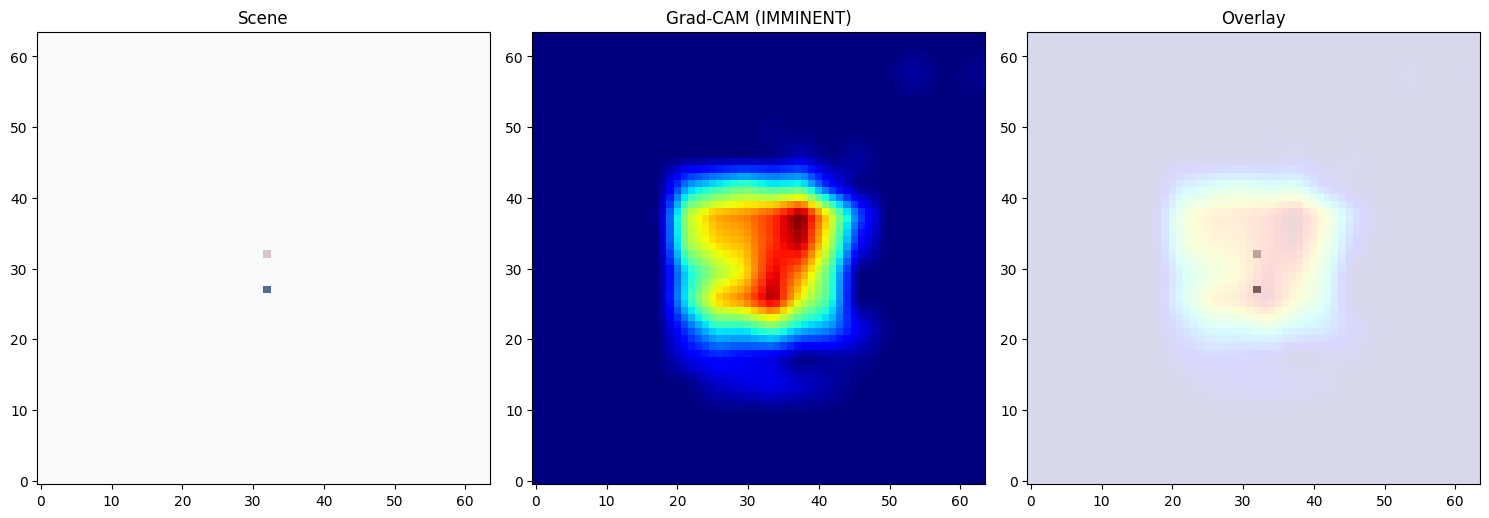

In [10]:
# a hand-made IMMINENT scene
def rasterise(snapshot, GRID=64, XMIN=0, XMAX=3.5, YMIN=0, YMAX=20):
    r = np.zeros((6,GRID,GRID), dtype=np.float32)
    for a in snapshot:
        cx = min(max(int((a["x"]-XMIN)/(XMAX-XMIN)*GRID),0),GRID-1)
        cy = min(max(int((a["y"]-YMIN)/(YMAX-YMIN)*GRID),0),GRID-1)
        if a["cls"]=="person":
            r[0,cy,cx]=1; r[2,cy,cx]=a["vx"]; r[3,cy,cx]=a["vy"]
        else:
            r[1,cy,cx]=1; r[4,cy,cx]=a["vx"]; r[5,cy,cx]=a["vy"]
    return r

snapshot = [
    {"cls":"person","x":1.75,"y":10.0,"vx":0.2,"vy":0.0},
    {"cls":"forklift","x":1.75,"y":8.5,"vx":0.0,"vy":3.0},
]
X_one = rasterise(snapshot)
sample = torch.tensor(X_one[None], dtype=torch.float32)

# Grad-CAM
acts, grads = {}, {}
def fh(m,i,o): acts["v"]=o.detach()
def bh(m,gi,go): grads["v"]=go[0].detach()
tl = model.res3.conv2
h1=tl.register_forward_hook(fh); h2=tl.register_full_backward_hook(bh)
model.zero_grad()
out = model(sample); pc = out.argmax(1).item()
out[0,pc].backward()
a=acts["v"][0]; g=grads["v"][0]
w=g.mean(dim=(1,2))
cam=torch.relu((w[:,None,None]*a).sum(0)); cam=cam/(cam.max()+1e-8)
h1.remove(); h2.remove()
print("Predicted:", ["SAFE","CAUTION","IMMINENT"][pc])

# plot
import matplotlib.pyplot as plt
cam_up = F.interpolate(cam[None,None],size=(64,64),mode="bilinear")[0,0].numpy()
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(X_one[0],origin="lower",cmap="Reds",alpha=.7); ax[0].imshow(X_one[1],origin="lower",cmap="Blues",alpha=.7); ax[0].set_title("Scene")
ax[1].imshow(cam_up,origin="lower",cmap="jet"); ax[1].set_title(f"Grad-CAM ({['SAFE','CAUTION','IMMINENT'][pc]})")
ax[2].imshow(cam_up,origin="lower",cmap="jet",alpha=.6); ax[2].imshow(X_one[0],origin="lower",cmap="Greys",alpha=.5); ax[2].imshow(X_one[1],origin="lower",cmap="Greys",alpha=.5); ax[2].set_title("Overlay")
plt.tight_layout(); plt.savefig("/kaggle/working/gradcam.png",dpi=100); plt.show()